In [47]:
# Download and extract the UCI dataset

import requests
import zipfile
import io
import os

url = "https://archive.ics.uci.edu/static/public/331/sentiment+labelled+sentences.zip"

response = requests.get(url)
response.raise_for_status()

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    z.extractall("/content/sentiment_dataset")

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")
base_path = "/content/sentiment_dataset/sentiment labelled sentences"

files = [
    "imdb_labelled.txt",
    "amazon_cells_labelled.txt",
    "yelp_labelled.txt"
]

dataframes = []

for file in files:
    path = os.path.join(base_path, file)

    df = pd.read_csv(
        path,
        sep="\t",
        header=None,
        names=["text", "sentiment"]
    )

    dataframes.append(df)

data = pd.concat(dataframes, ignore_index=True)

print("Dataset shape:", data.shape)
print()
print(data.head())

Libraries imported successfully!
Dataset shape: (2748, 2)

                                                text  sentiment
0  A very, very, very slow-moving, aimless movie ...          0
1  Not sure who was more lost - the flat characte...          0
2  Attempting artiness with black & white and cle...          0
3       Very little music or anything to speak of.            0
4  The best scene in the movie was when Gerardo i...          1


In [49]:
print("Missing values:")
print(data.isnull().sum())

print("\nSentiment distribution:")
print(data["sentiment"].value_counts())

print("\nDataset information:")
print(data.info())

Missing values:
text         0
sentiment    0
dtype: int64

Sentiment distribution:
sentiment
1    1386
0    1362
Name: count, dtype: int64

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2748 entries, 0 to 2747
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       2748 non-null   object
 1   sentiment  2748 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 43.1+ KB
None


In [50]:
data["label"] = data["sentiment"].map({
    0: "Negative",
    1: "Positive"
})

print(data.head())

                                                text  sentiment     label
0  A very, very, very slow-moving, aimless movie ...          0  Negative
1  Not sure who was more lost - the flat characte...          0  Negative
2  Attempting artiness with black & white and cle...          0  Negative
3       Very little music or anything to speak of.            0  Negative
4  The best scene in the movie was when Gerardo i...          1  Positive


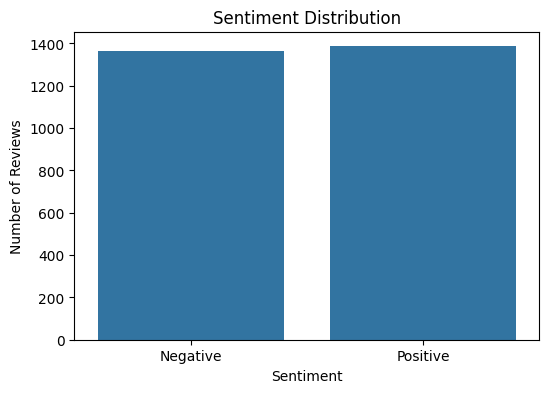

In [51]:
#visualization
plt.figure(figsize=(6, 4))

sns.countplot(
    data=data,
    x="label"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [52]:
X = data["text"]
y = data["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 2198
Testing samples: 550


In [53]:
#TF-IDF
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training matrix:", X_train_tfidf.shape)
print("Testing matrix:", X_test_tfidf.shape)

Training matrix: (2198, 4209)
Testing matrix: (550, 4209)


In [54]:
#Logistic Regression
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

logistic_predictions = logistic_model.predict(
    X_test_tfidf
)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print(
    f"Logistic Regression Accuracy: "
    f"{logistic_accuracy:.2%}"
)

Logistic Regression Accuracy: 81.09%


In [55]:
#Naive Byes
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

nb_predictions = nb_model.predict(
    X_test_tfidf
)

nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

print(
    f"Naive Bayes Accuracy: "
    f"{nb_accuracy:.2%}"
)

Naive Bayes Accuracy: 80.91%


In [56]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes"
    ],
    "Accuracy": [
        logistic_accuracy,
        nb_accuracy
    ]
})

results["Accuracy (%)"] = results["Accuracy"] * 100

print(results)

                 Model  Accuracy  Accuracy (%)
0  Logistic Regression  0.810909     81.090909
1          Naive Bayes  0.809091     80.909091


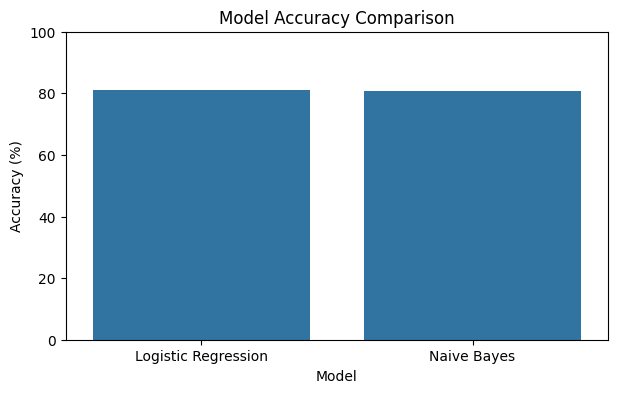

In [57]:
#Visualization
plt.figure(figsize=(7, 4))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy (%)"
)

plt.ylim(0, 100)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xlabel("Model")

plt.show()

In [58]:
if logistic_accuracy >= nb_accuracy:
    best_name = "Logistic Regression"
    best_predictions = logistic_predictions
else:
    best_name = "Naive Bayes"
    best_predictions = nb_predictions

print("Best Model:", best_name)
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=["Negative", "Positive"]
    )
)

Best Model: Logistic Regression

Classification Report:

              precision    recall  f1-score   support

    Negative       0.79      0.84      0.81       273
    Positive       0.83      0.79      0.81       277

    accuracy                           0.81       550
   macro avg       0.81      0.81      0.81       550
weighted avg       0.81      0.81      0.81       550



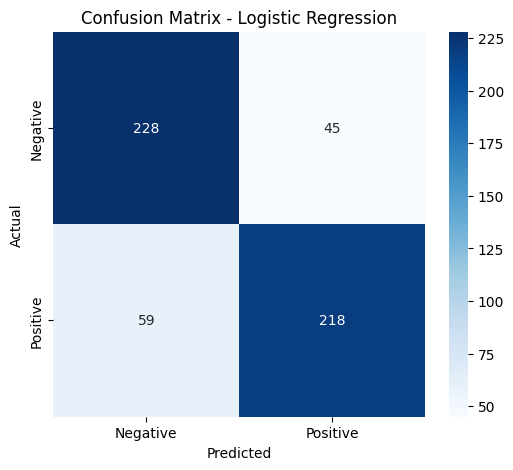

In [59]:
cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title(f"Confusion Matrix - {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [71]:
custom_reviews = [
    "\nI absolutely loved this product. It was amazing!",
    "\nThe service was terrible and completely disappointing.",
    "\nThis movie was okay but nothing special.",
    "\nExcellent quality and very good experience."
]

custom_tfidf = tfidf.transform(custom_reviews)

custom_predictions = logistic_model.predict(custom_tfidf)

for review, prediction in zip(custom_reviews, custom_predictions):

    sentiment = "POSITIVE" if prediction == 1 else "NEGATIVE!"

    print(f"Review: {review}")
    print(f"Prediction: {sentiment}")


Review: 
I absolutely loved this product. It was amazing!
Prediction: POSITIVE
Review: 
The service was terrible and completely disappointing.
Prediction: NEGATIVE!
Review: 
This movie was okay but nothing special.
Prediction: POSITIVE
Review: 
Excellent quality and very good experience.
Prediction: POSITIVE
